In [1]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[0])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
import scipy
import pickle
import sigpy as sp
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import SimpleITK as sitk
import recon_plot_helpers

### 1. Load MoCo Image

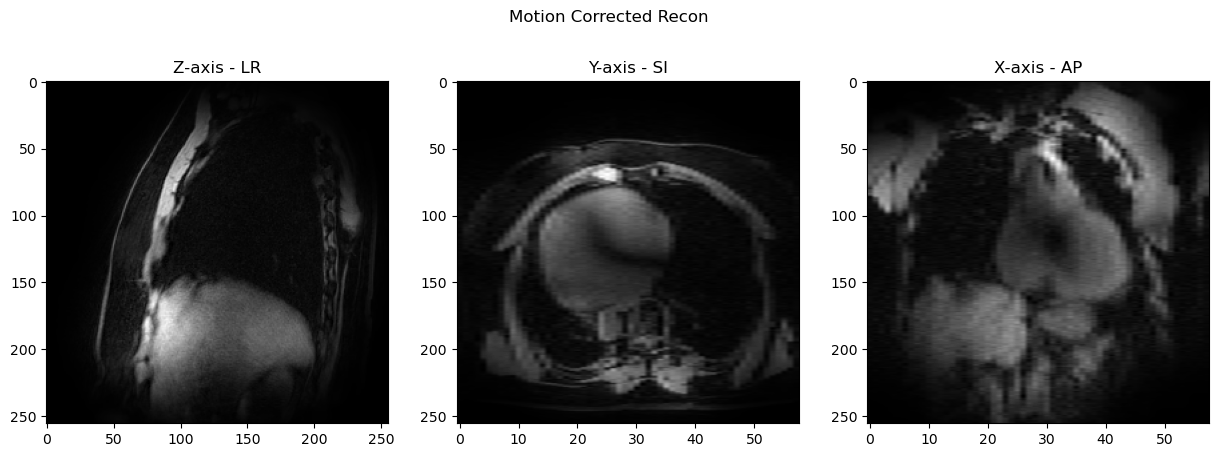

In [2]:
## Base directory where everything is located
base_dir = f"/home/lilianae/projects/naf_clean/admm_results/subject3_mid0283_nifti_files"

## Lambda = motion corrected image
lam_path = os.path.join(base_dir,"lam.nii")
ref_img = sitk.GetArrayFromImage(sitk.ReadImage(lam_path))

# Extract center indices for plotting
z_idx = 44
y_idx = 128
# Plot at the center of the Liver ROI
fig, ax = recon_plot_helpers.plot_recons_all_axes(
    ref_img, 
    z_idx=z_idx, 
    y_idx=y_idx, 
    column_titles=True,
    title="Motion Corrected Recon"
)

### 2. Visualize interface coordinate

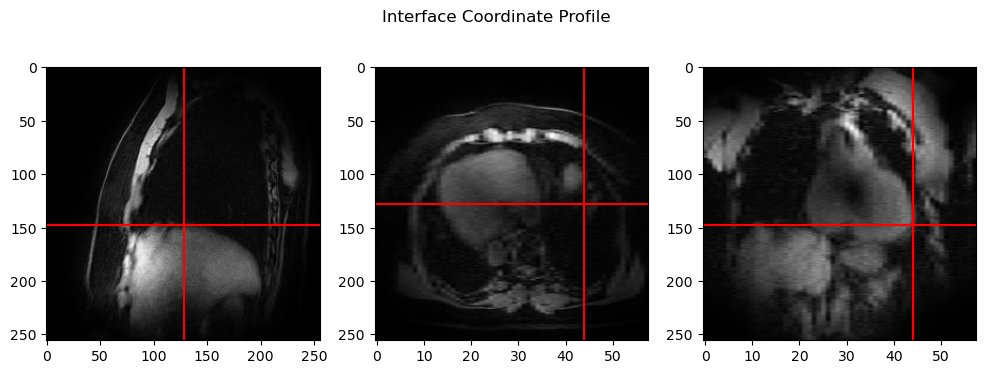

In [ ]:
import numpy as np
Nz, Ny, Nx = ref_img.shape
# Convert grayscale to RGB for colored overlays
vis_img = np.stack([ref_img]*3, axis=-1)  # shape: (Z, Y, X, 3)

# Interface coordinates
# ## closer to heart
# z_i, y_i, x_i = (44, 148, 128)
## closer to liver
z_i, y_i, x_i = (44, 148, 128)
interface_coord = (z_i, y_i, x_i)

# Set red intensity (255 if uint8; or max_val for float data)
red_val = vis_img.max()

# Z-profile line
vis_img[:, y_i, x_i, 0] = red_val  # red channel
# Y-profile line
vis_img[z_i, :, x_i, 0] = red_val
# X-profile line
vis_img[z_i, y_i, :, 0] = red_val

import matplotlib.pyplot as plt

def show_with_red_lines(img, z_i, y_i, x_i):
    fig, axs = plt.subplots(1, 3, figsize=(12,4))

    # Axial (XY at Z = z_i)
    axs[0].imshow(np.fliplr(img[z_i]), cmap="gray")
    axs[0].axhline(y_i, color="red")
    axs[0].axvline(x_i, color="red")

    # Coronal (XZ at Y = y_i)
    axs[1].imshow(np.rot90(img[:, y_i, :],k=-3), cmap="gray", aspect=Nz/Nx)
    axs[1].axhline(x_i, color="red")
    axs[1].axvline(z_i, color="red")

    # Sagittal (YZ at X = x_i)
    axs[2].imshow(np.rot90(img[:, :, x_i], k=-1), cmap="gray", aspect=Nz/Ny)
    axs[2].axhline(y_i, color="red")
    axs[2].axvline(z_i, color="red")

    plt.suptitle("Interface Coordinate Profile")
    plt.show()

show_with_red_lines(ref_img, z_i, y_i, x_i)

Determine minimum and maximum signal

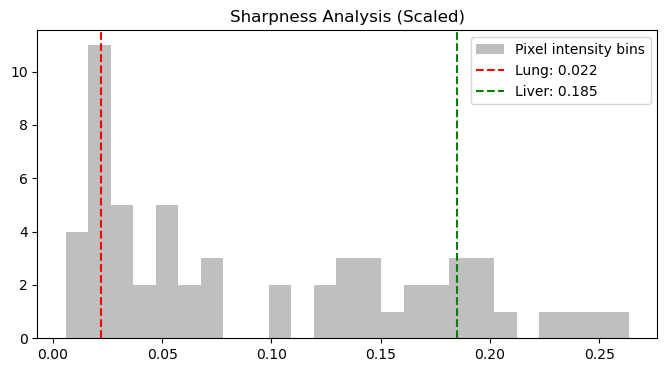

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

def calculate_analytical_bounds_rescaled(profile):
    # --- 1. Rescale to 0-100 range to help the KDE ---
    p_min, p_max = profile.min(), profile.max()
    # Avoid division by zero
    rescaled = 100 * (profile - p_min) / (p_max - p_min + 1e-9)

    # --- 2. Create KDE with adjusted bandwidth ---
    # 'bw_method' controls how smooth the curve is. 
    # If it's too smooth, it hides the two peaks.
    kde = gaussian_kde(rescaled, bw_method=0.2) 
    x_range = np.linspace(-10, 110, 1000)
    density = kde(x_range)

    # --- 3. Find Peaks ---
    # With a 0-100 scale, we can use more predictable distances
    peaks, _ = find_peaks(density, distance=100, prominence=0.01)
    
    if len(peaks) >= 2:
        # Get highest two peaks
        best_peaks = peaks[np.argsort(density[peaks])][-2:]
        mode_indices = sorted(best_peaks)
        
        # Convert back to the original scale
        val_min_rescaled = x_range[mode_indices[0]]
        val_max_rescaled = x_range[mode_indices[1]]
        
        val_min = p_min + (val_min_rescaled / 100) * (p_max - p_min)
        val_max = p_min + (val_max_rescaled / 100) * (p_max - p_min)
        method = "KDE on Rescaled Data"
    else:
        # High-Resolution Percentile fallback
        val_min = np.percentile(profile, 15)
        val_max = np.percentile(profile, 85)
        method = "Percentile Fallback"

    return val_min, val_max, method


profile_si = ref_img[:, 148, 128]
v_min, v_max, method = calculate_analytical_bounds_rescaled(profile_si)

plt.figure(figsize=(8, 4))
plt.hist(profile_si, bins=25, color='gray', alpha=0.5, label='Pixel intensity bins')
plt.axvline(v_min, color='red', linestyle='--', label=f'Lung: {v_min:.3f}')
plt.axvline(v_max, color='green', linestyle='--', label=f'Liver: {v_max:.3f}')
plt.title(f"Sharpness Analysis (Scaled)")
plt.legend()
plt.show()

In [71]:
## Take from histogram binning
threshold = (v_min + v_max) / 2.0  # 0.1035

# 2. Use the Interpolated Profile (profile_interp from 1000 pts)
# Find where the profile crosses the threshold
# This is the "Center" of the transition
z_center_idx = np.argmin(np.abs(profile_si - threshold))

# 3. Calculate Sharpness via Gradient
# dz is your spacing (e.g., 5mm / (1000/58))
dz=(5.0/(1000/58))
gradient = np.abs(np.gradient(profile_si, dz))
peak_grad = gradient[z_center_idx]

# 4. HWHM Calculation
# For a Gaussian-like transition, HWHM relates to the peak gradient:
# Intensity_Change = val_max - val_min
# HWHM = (Intensity_Change) / (2 * peak_grad)
intensity_delta = v_max - v_min
hwhm_mm = intensity_delta / (2 * peak_grad)

sharpness = 1.0 / hwhm_mm
print(f"Calculated Sharpness: {sharpness:.4f} mm⁻¹")

Calculated Sharpness: 0.0618 mm⁻¹


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# def plot_hwhm_analysis(z_fine, profile_interp, gradient, z_center_idx, hwhm_mm, val_min, val_max):
#     # Setup coordinates for plotting
#     z_center = z_fine[z_center_idx]
#     threshold = (val_min + val_max) / 2.0
    
#     fig, ax1 = plt.subplots(figsize=(10, 6), facecolor='white')
    
#     # --- 1. Plot Intensity Transition ---
#     ax1.plot(z_fine, profile_interp, color='black', linewidth=2, label='Intensity Profile')
#     # ax1.axhline(val_min, color='gray', linestyle='--', alpha=0.5, label='Lung Baseline')
#     # ax1.axhline(val_max, color='gray', linestyle='--', alpha=0.5, label='Liver Baseline')
#     # ax1.axhline(threshold, color='orange', linestyle=':', label='50% Threshold')
    
#     ax1.set_ylabel('Signal Intensity', fontsize=12)
#     ax1.set_xlabel('Z-Position (Superior-Inferior) [mm]', fontsize=12)
    
#     # --- 2. Plot Gradient (Line Spread Function) on Twin Axis ---
#     # ax2 = ax1.twinx()
#     # ax2.plot(z_fine, gradient, color='red', alpha=0.6, label='Gradient (LSF)')
#     # ax2.fill_between(z_fine, 0, gradient, color='red', alpha=0.1)
    
#     # --- 3. Mark HWHM ---
#     # HWHM is the distance from center to half-peak. 
#     # We draw a horizontal line at the peak_grad/2 level to show the width.
#     peak_grad = gradient[z_center_idx]
#     half_grad = peak_grad / 2.0
    
#     # Drawing the HWHM "Bar"
#     hwhm_start = z_center - hwhm_mm
#     hwhm_end = z_center # Since it's HALF width, it goes from center to one side
    
#     # ax2.hlines(y=half_grad, xmin=hwhm_start, xmax=hwhm_end, 
#     #            color='blue', linewidth=3, label=f'HWHM: {hwhm_mm:.2f} mm')
    
#     # # Vertical line at the interface center
#     # ax1.axvline(z_center, color='green', linestyle='-', alpha=0.3, label='Anatomical Interface')

#     # Formatting
#     plt.title(f"Edge Sharpness Analysis (Z-Axis) (1/HWHM)\nSharpness = {1/hwhm_mm:.4f} $mm^{{-1}}$", fontsize=14)
#     ax1.legend(loc='upper left', fontsize=9)
#     # ax2.legend(loc='upper right', fontsize=9)
    
#     ax1.grid(True, alpha=0.2)
#     plt.tight_layout()
#     plt.show()

In [86]:
import numpy as np
import matplotlib.pyplot as plt

def plot_hwhm_analysis(z_fine, profile_interp, gradient, z_center_idx, hwhm_mm, val_min, val_max):
    # Setup coordinates for plotting
    z_center = z_fine[z_center_idx]
    threshold = (val_min + val_max) / 2.0
    peak_grad = gradient[z_center_idx]
    half_grad = peak_grad / 2.0
    
    # Initialize Side-by-Side subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
    
    # --- LEFT PLOT: Intensity Profile (Edge Transition) ---
    ax1.plot(z_fine, profile_interp, color='black', linewidth=2.5, label='Interpolated Profile')
    # ax1.axhline(val_min, color='gray', linestyle='--', alpha=0.6, label=f'Lung: {val_min:.3f}')
    # ax1.axhline(val_max, color='gray', linestyle='--', alpha=0.6, label=f'Liver: {val_max:.3f}')
    # ax1.axhline(threshold, color='orange', linestyle=':', label='50% Intensity')
    # ax1.axvline(z_center, color='green', linestyle='-', alpha=0.3, label='Interface Center')
    
    ax1.set_title("Edge Transition (Intensity)", fontsize=13)
    ax1.set_ylabel('Normalized Signal Intensity', fontsize=11)
    ax1.set_xlabel('SI Position [mm]', fontsize=11)
    ax1.legend(loc='upper left', fontsize=9)
    ax1.grid(True, alpha=0.2)

    # --- RIGHT PLOT: Line Spread Function (Gradient) ---
    ax2.plot(z_fine, gradient, color='red', linewidth=2, label='Gradient (LSF)')
    ax2.fill_between(z_fine, 0, gradient, color='red', alpha=0.1)
    
    # Drawing the HWHM "Bar"
    # HWHM spans from the center to one side at the half-height of the LSF peak
    hwhm_start = z_center - hwhm_mm
    hwhm_end = z_center 
    
    ax2.hlines(y=half_grad, xmin=hwhm_start, xmax=hwhm_end, 
               color='blue', linewidth=4, label=f'HWHM: {hwhm_mm:.2f} mm')
    # ax2.axvline(z_center, color='green', linestyle='-', alpha=0.3)
    ax2.axhline(half_grad, color='blue', linestyle=':', alpha=0.4)

    ax2.set_title(f"Line Spread Function\nSharpness: {1/hwhm_mm:.4f} $mm^{{-1}}$", fontsize=13)
    ax2.set_ylabel('Gradient Magnitude', fontsize=11)
    ax2.set_xlabel('SI Position [mm]', fontsize=11)
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(True, alpha=0.2)

    plt.suptitle(f"Z-Axis Through-Plane Sharpness Analysis", fontsize=15, y=1.05)
    plt.tight_layout()
    plt.show()

# Execution assumes z_fine, profile_interp, gradient, etc. are already computed
# plot_hwhm_analysis(z_fine, profile_interp, gradient_interp, z_center_idx, hwhm_mm, val_min, val_max)

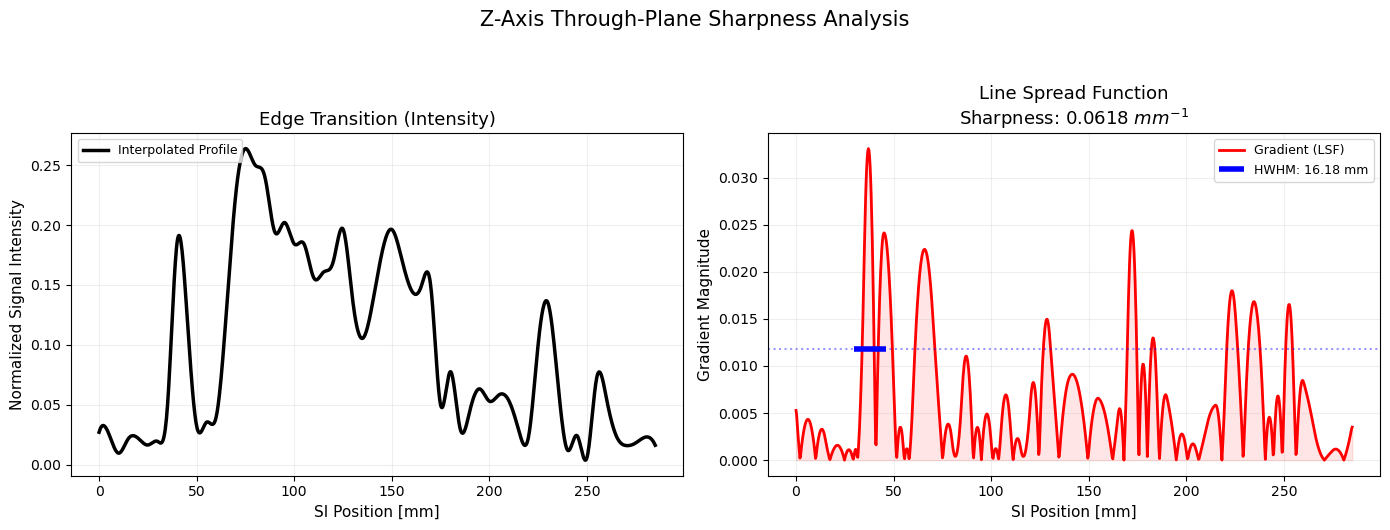

In [87]:
from scipy.interpolate import CubicSpline

# 1. Define the original 58 physical coordinates
z_original = np.linspace(0, (58 - 1) * 5.0, 58)

# 2. Create the Interpolator using your raw 58-point profile
# Make sure 'profile_si' here is the raw one from ref_img[:, 148, 128]
cs = CubicSpline(z_original, profile_si)

# 3. Generate the 1000-point smooth profile
max_z = (58 - 1) * 5.0 
z_fine = np.linspace(0, max_z, 1000)
profile_interp = cs(z_fine)  # This is now shape (1000,)

# 4. Calculate Gradient on the INTERPOLATED profile
dz = z_fine[1] - z_fine[0]
gradient_interp = np.abs(np.gradient(profile_interp, dz))

# 5. Find the new center index in the 1000-point array
threshold = (v_min + v_max) / 2.0
z_center_idx = np.argmin(np.abs(profile_interp - threshold))

# 6. Now call the plot function with the matching 1000-point arrays
plot_hwhm_analysis(z_fine, profile_interp, gradient_interp, z_center_idx, hwhm_mm, v_min, v_max)

## 2. Smooth profile over a few pixels

In [31]:
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import CubicSpline

# 1. SI profile at interface coordinate (y_i, x_i)
raw_profile = ref_img[:, y_i, x_i] 
z_coords_raw = np.linspace(0, (58-1) * 5.0, 58)

# 2. Smooth to remove noise (sigma=1 is usually plenty)
smoothed = gaussian_filter1d(raw_profile, sigma=1.0)

# 3. Averaging 

# 4. Interpolate to 1000 points for precision
cs = CubicSpline(z_coords, smoothed)
z_fine = np.linspace(0, z_coords[-1], 1000)
profile_fine = cs(z_fine)

# 5. Calculate Gradient (Line Spread Function)
# The peak of this is your "sharpest" point
lsf = np.abs(np.gradient(profile_fine, z_fine[1] - z_fine[0]))

ValueError: The length of `y` along `axis`=0 doesn't match the length of `x`

In [32]:
def calculate_hwhm(image, interface_coord, voxel_spacing):
    # Take 1D profiles along Z, Y, and X axes passing through the interface_coord
    z, y, x = interface_coord
    profiles = {
        'Z-axis (LR)': (image[:, y, x], voxel_spacing[0]),
        'Y-axis (SI)': (image[z, :, x], voxel_spacing[1]),
        'X-axis (AP)': (image[z, y, :], voxel_spacing[2])
    }

    sharpness_results = {}
    gradient_results = {}

    for i, (label, (profile, spacing)) in enumerate(profiles.items()):
        # 1. Calculate the gradient (Line Spread Function)
        gradient = np.abs(np.gradient(profile))
        gradient_results[label] = gradient
        
        # 2. Find peak of transition
        peak_idx = np.argmax(gradient)
        max_val = gradient[peak_idx]
        
        # Find Half-Width at Half-Maximum (HWHM) in pixels - distance from peak to where the gradient drops to 50%
        half_max = max_val / 2.0
        
        # Find the indices where the gradient is above half_max
        idx_above_half_max = np.where(gradient >= half_max)[0]
        
        if len(idx_above_half_max) > 0:
            # Full Width at Half Max (FWHM) in pixels
            fwhm_px = idx_above_half_max[-1] - idx_above_half_max[0]
            hwhm_px = fwhm_px / 2.0
            
            # Convert to mm using the provided spacing for that axis
            hwhm_mm = hwhm_px * voxel_spacing[i]
            sharpness_results[label] = 1.0/hwhm_mm

        else:
            sharpness_results[label] = 0.0

    return gradient_results, sharpness_results


# 1. Determine liver/background interface coordinate
interface_coord = (44, 148, 128)
voxel_spacing = [5.0, 1.172, 1.172]
image = ref_img

gradient_results, sharpness_results = calculate_hwhm(image, interface_coord, voxel_spacing)

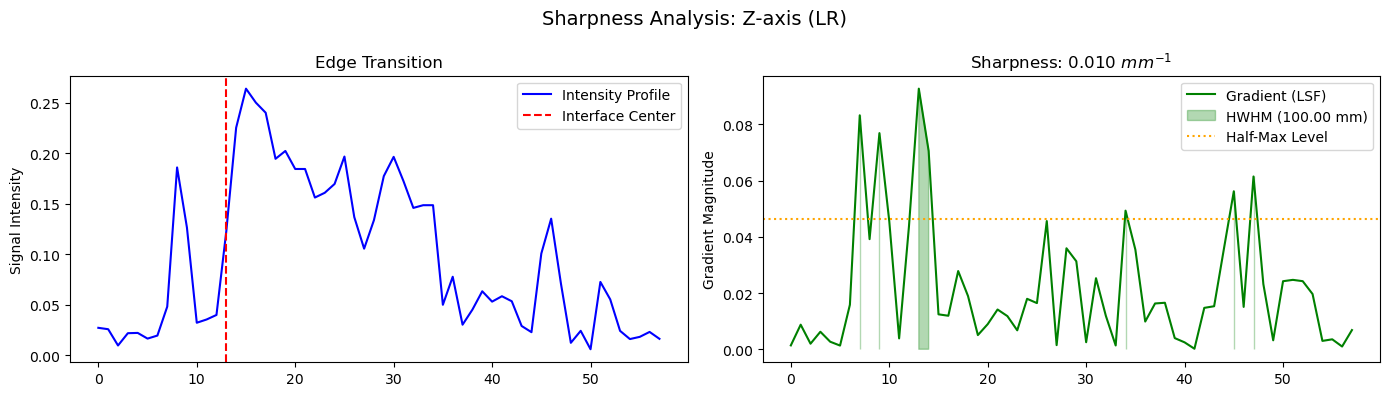

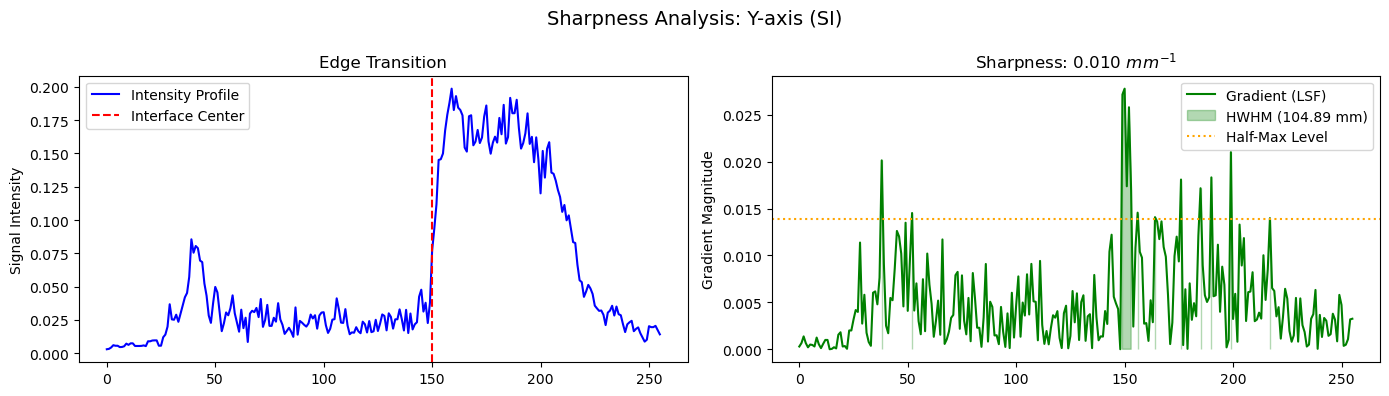

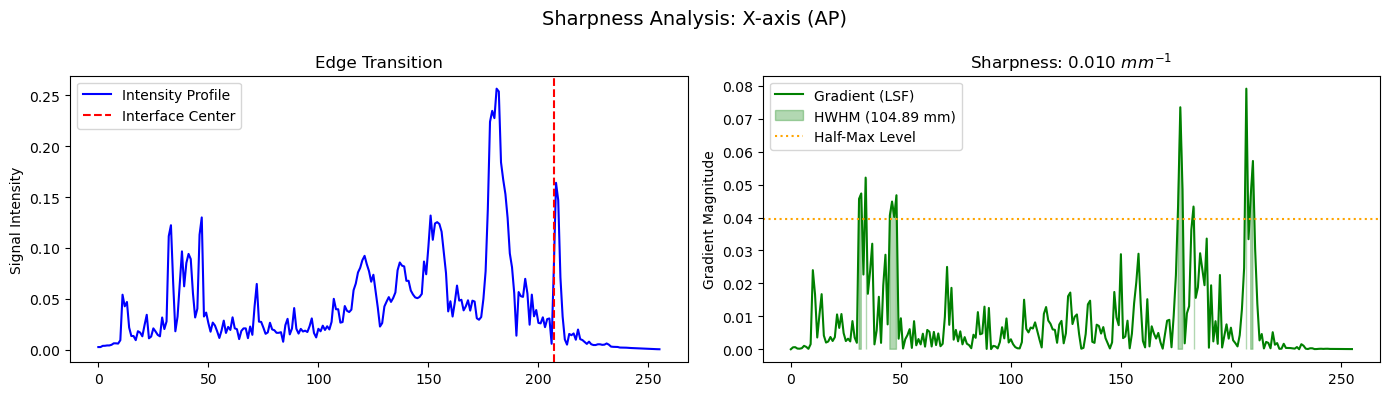

In [33]:
import matplotlib.pyplot as plt
import numpy as np

def compute_and_plot_sharpness(image, interface_coord, voxel_spacing):
    z, y, x = interface_coord
    profiles = {
        'Z-axis (LR)': (image[:, y, x], voxel_spacing[0]),
        'Y-axis (SI)': (image[z, :, x], voxel_spacing[1]),
        'X-axis (AP)': (image[z, y, :], voxel_spacing[2])
    }

    sharpness_results = {}

    for i, (label, (profile, spacing)) in enumerate(profiles.items()):
        # 1. Compute Gradient (Line Spread Function)
        gradient = np.abs(np.gradient(profile))
        peak_idx = np.argmax(gradient)
        max_val = gradient[peak_idx]
        half_max = max_val / 2.0
        
        # 2. Find HWHM
        above_half_max = np.where(gradient >= half_max)[0]
        if len(above_half_max) < 2: continue
        
        fwhm_px = above_half_max[-1] - above_half_max[0]
        hwhm_px = fwhm_px / 2.0
        hwhm_mm = hwhm_px * spacing
        sharpness = 1.0 / hwhm_mm if hwhm_mm > 0 else 0
        sharpness_results[label] = sharpness

        # 3. Visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
        fig.suptitle(f"Sharpness Analysis: {label}", fontsize=14)

        # Plot Intensity Profile
        ax1.plot(profile, color='blue', label='Intensity Profile')
        ax1.axvline(peak_idx, color='red', linestyle='--', label='Interface Center')
        ax1.set_title("Edge Transition")
        ax1.set_ylabel("Signal Intensity")
        ax1.legend()

        # Plot Gradient & HWHM
        ax2.plot(gradient, color='green', label='Gradient (LSF)')
        ax2.fill_between(range(len(gradient)), 0, gradient, where=(gradient >= half_max), 
                         color='green', alpha=0.3, label=f'HWHM ({hwhm_mm:.2f} mm)')
        ax2.axhline(half_max, color='orange', linestyle=':', label='Half-Max Level')
        ax2.set_title(f"Sharpness: {sharpness:.3f} $mm^{{-1}}$")
        ax2.set_ylabel("Gradient Magnitude")
        ax2.legend()

        plt.tight_layout()
        plt.show()

    return sharpness_results

# Execute
results = compute_and_plot_sharpness(ref_img, interface_coord, voxel_spacing=voxel_spacing)

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d

def compute_si_sharpness(profile, spacing_z):
    # 1. Smooth over a few pixels to kill high-frequency noise
    # Sigma=1 roughly smooths over a 3-pixel window
    smoothed_profile = gaussian_filter1d(profile, sigma=1)
    
    # 2. Average Top and Bottom to define the "Step"
    # This defines what '100%' and '0%' signal levels are
    top_steady_state = np.mean(smoothed_profile[:5])    # Lung signal
    bottom_steady_state = np.mean(smoothed_profile[-5:]) # Liver signal
    
    # 3. Interpolate up to 1000 points
    # This turns our 58 points into a high-resolution continuous line
    x_original = np.linspace(0, len(profile) * spacing_z, len(profile))
    x_new = np.linspace(0, x_original[-1], 1000)
    
    f_interp = interp1d(x_original, smoothed_profile, kind='cubic')
    high_res_profile = f_interp(x_new)
    
    # 4. Calculate Gradient (Line Spread Function)
    lsf = np.abs(np.gradient(high_res_profile, x_new[1] - x_new[0]))
    
    # 5. Determine HWHM
    peak_idx = np.argmax(lsf)
    max_lsf = lsf[peak_idx]
    half_max = max_lsf / 2.0
    
    # Find the indices where the gradient exceeds half-max
    indices_above_hm = np.where(lsf >= half_max)[0]
    fwhm_mm = (indices_above_hm[-1] - indices_above_hm[0]) * (x_new[1] - x_new[0])
    hwhm_mm = fwhm_mm / 2.0
    
    # Sharpness = 1 / HWHM
    sharpness = 1.0 / hwhm_mm
    
    return sharpness, x_new, high_res_profile, lsf